In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Разведочный анализ данных для hirehi. 

In [3]:
palette = ["#1f2d3a", "#0f766e", "#2a4d69"]

### Работа с исходными данными

In [4]:
data = pd.read_csv('vacancys_final.csv')
data.sample(3)

,Unnamed: 0,id,title,category,company,format,level,salary,link,skills
4556,4556,31589,Product Manager,management,MAX,гибрид Москва,middle,~ от 248 800 ₽,https://hirehi.ru/management/product-manager-3...,"['sql', 'a/b-тесты', 'гипотезы', 'метрики', 'п..."
7586,7586,27219,laravel developer,development,NDA,удалённо,lead,~ от 501 500 ₽,https://hirehi.ru/development/laravel-develope...,"['php', 'laravel', 'devops', 'docker', 'баланс..."
1215,1215,35441,product analyst,analytics,Альфа-Банк,гибрид Москва,senior,от 250 000 ₽,https://hirehi.ru/analytics/product-analyst-35441,"['fintech', 'sql', 'analytics', 'ltv', 'bankin..."


Оценим, как распределено количество требуемых инструментов для различных вакансий. Для этого создадим дополнительный признак - `skills_num`.

In [5]:
def get_len(x):
    if x == '[]':
        return 0
    return len(x[1:-2].split(', '))

In [6]:
data['skills_num'] = data['skills'].apply(lambda x: get_len(x))
skills_length_grouped = data['skills_num'].value_counts()
skills_length_grouped

skills_num
10    1353
15    1199
12    1198
14    1193
13     981
11     959
9      443
8      347
7      246
16     238
6      176
5      112
4       65
17      61
0       55
20      39
18      29
3       27
19      18
2       11
1        4
Name: count, dtype: int64

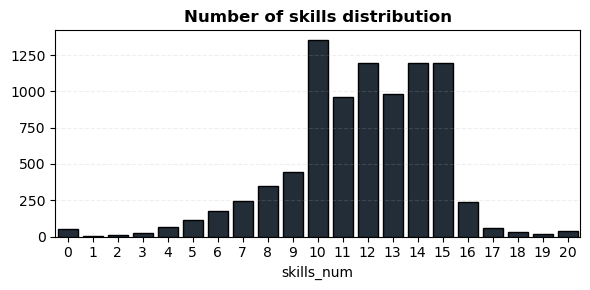

In [8]:
fig, ax = plt.subplots(figsize=(6, 3))

sns.barplot(
    x=skills_length_grouped.index,
    y=skills_length_grouped.values,
    color=palette[0],
    edgecolor='black'
)
ax.grid(axis='y', linestyle='--', alpha=0.2)
ax.set_title('Number of skills distribution', fontweight='bold')
plt.tight_layout()